# Utilities

In [1]:
# --- Imports

import numpy as np
import qutip as qt
import torch
import math
from scipy.optimize import minimize

from tqdm import tqdm
import h5py
import glob

import os
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib import colormaps
import matplotlib.colors as colors

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Global settings

file_directory = r'C:\Users\jah499\OneDrive - Rutgers University\Research\Sideband Optimal Control\optimizer_code\RELEASE_v1'

default_dtype = torch.float32
complex_dtype = torch.complex64
numpy_tolerance = 1e-6
MIXED_PRECISION = True
QUBIT_THETA_LOWER_BOUND = torch.pi * 20 / 180
QUBIT_THETA_UPPER_BOUND = 2 * torch.pi  # qubit theta bounded to [QUBIT_THETA_LOWER_BOUND, QUBIT_THETA_UPPER_BOUND]
THETA_ZERO_TOL = 1e-4  # radians, zero tolerance for qubit ge rotation thetas when sweeping over amplitude, thethas below this value are set to zero

# --- Configuration information

torch.set_default_dtype(default_dtype)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print('--- Notes')
print('You can use a CUDA-enabled GPU to run the optimization.')
print('--- Devices')
print('Device (GPU) count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('CUDA available. Current available device:', torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print('No CUDA device available; skipping device name query.')

print('Using device:', device)

print('Mixed precision via autocast available for CUDA:', torch.amp.autocast_mode.is_autocast_available('cuda'))

print('--- Datatypes')
print(f"Default dtype: {torch.get_default_dtype()}")
print('Default complex dtype:', complex_dtype)
print('Using mixed precision (bfloat16):', MIXED_PRECISION)

--- Notes
You can use a CUDA-enabled GPU to run the optimization.
--- Devices
Device (GPU) count: 1
CUDA available. Current available device: NVIDIA GeForce RTX 5070 Ti
Using device: cuda:0
Mixed precision via autocast available for CUDA: True
--- Datatypes
Default dtype: torch.float32
Default complex dtype: torch.complex64
Using mixed precision (bfloat16): True


In [34]:
def next_file_index(datapath, prefix=''):
    """Searches directories for files of the form *_prefix* and returns next number
        in the series"""
    dirlist=glob.glob(os.path.join(datapath,'*_'+prefix+'*'))
    dirlist.sort()
    try:
        ii=int(os.path.split(dirlist[-1])[-1].split('_')[0])+1
    except:
        ii=0
    return ii  

def get_next_filename(datapath, prefix, suffix=''):
    ii = next_file_index(datapath, prefix)
    return "%05d_" % (ii) + prefix + suffix

def save_data(file_name, save_path, dictionary, config=None):
    file_path = save_path + '\\' + get_next_filename(save_path, file_name, '.h5')

    with h5py.File(file_path, 'w-') as f:
        for ii in dictionary:
            f.create_dataset(ii, data=dictionary[ii])
        if config:
            for ii in config:
                f.attrs[ii] = config[ii]

    print('Data saved to: ' + file_path)

def get_state(qubit_n, osc_n, n_osc_max):
        return qt.tensor(qt.basis(n_osc_max, osc_n), qt.basis(3, qubit_n))

def is_unitary(u, tol=numpy_tolerance):
    """Check if a matrix u is unitary within a given tolerance."""
    identity = np.eye(u.shape[0])
    product = np.matmul(u.conj().T, u)
    return np.allclose(product, identity, atol=tol)

class Utils:
    
    def __init__(self, n_osc_max, stark_shift_f, stark_shift_e, stark_shift_osc, epsilon, epsilon_q, chi_e, chi_f, tau_q, sb_ramp_offset, qubit_pulse_theta, verbose=False):
        self.n_osc_max = n_osc_max
        self.stark_shift_f = stark_shift_f
        self.stark_shift_e = stark_shift_e
        self.stark_shift_osc = stark_shift_osc
        self.epsilon = epsilon
        self.epsilon_q = epsilon_q
        self.chi_e = chi_e
        self.chi_f = chi_f
        self.tau_q = tau_q
        self.sb_ramp_offset = sb_ramp_offset  # Applies to time of dynamical phase during sideband pulse
        self.qubit_pulse_theta = qubit_pulse_theta
        self.verbose = verbose
        self.theta_zero_tol = THETA_ZERO_TOL  # radians

        if self.verbose:
            dynamical_phase_f_2pi_resonant = np.mod(180 / np.pi * 2*np.pi*(self.stark_shift_f - self.stark_shift_osc + self.chi_f * (self.n_osc_max - 1)) * (self.sb_ramp_offset + 1 / 2 / np.sqrt(self.n_osc_max * self.epsilon**2)), 360)
            print('Dynamical phase (QuTiP, degree) for 2pi sideband pulse resonant with |f, n_osc_max-1>-|g, n_osc_max> transition:', dynamical_phase_f_2pi_resonant)
    
    def qubit_ge_rot(self, theta, phi, delta=0):
        rot_mat = qt.Qobj(np.zeros((3*self.n_osc_max, 3*self.n_osc_max)), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
        if self.qubit_pulse_theta == 'length':
            m = 1
        elif self.qubit_pulse_theta == 'amp':
            m = theta / np.pi
        if self.qubit_pulse_theta == 'amp' and np.any(np.abs(theta) < self.theta_zero_tol):  # Handle theta=0 case
            for ii in range(0, self.n_osc_max):
                rot_mat += np.e**(-1j * 2 * np.pi * (self.chi_e * ii - delta) / 2 * self.tau_q) * qt.Qobj(self.get_state(0, ii) * self.get_state(0, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                rot_mat += np.e**(-1j * 2 * np.pi * (self.chi_e * ii - delta) / 2 * self.tau_q) * qt.Qobj(self.get_state(1, ii) * self.get_state(1, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                rot_mat += np.e**(-1j*2*np.pi*self.chi_f*ii*self.tau_q) * qt.Qobj(self.get_state(2, ii) * self.get_state(2, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
        else:
            for ii in range(0, self.n_osc_max):
                rate = np.sqrt(((self.chi_e * ii - delta) / 2)**2 + (m*self.epsilon_q)**2)
                theta_n = theta * rate / np.sqrt((delta/2)**2 + (m*self.epsilon_q)**2)
                # Diagonal
                rot_mat += np.e**(-1j * 2 * np.pi * (self.chi_e * ii - delta) / 2 * self.tau_q) * (np.cos(theta_n/2) + 1j * (self.chi_e * ii - delta) / 2 / rate * np.sin(theta_n/2)) * qt.Qobj(self.get_state(0, ii) * self.get_state(0, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                rot_mat += np.e**(-1j * 2 * np.pi * (self.chi_e * ii - delta) / 2 * self.tau_q) * (np.cos(theta_n/2) - 1j * (self.chi_e * ii - delta) / 2 / rate * np.sin(theta_n/2)) * qt.Qobj(self.get_state(1, ii) * self.get_state(1, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                rot_mat += np.e**(-1j*2*np.pi*self.chi_f*ii*self.tau_q) * qt.Qobj(self.get_state(2, ii) * self.get_state(2, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                # Off-diagonal
                rot_mat += np.e**(-1j * 2 * np.pi * (self.chi_e * ii - delta) / 2 * self.tau_q) * (-m*self.epsilon_q/rate*np.exp(1j*phi)*np.sin(theta_n/2)) * qt.Qobj(self.get_state(0, ii) * self.get_state(1, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                rot_mat += np.e**(-1j * 2 * np.pi * (self.chi_e * ii - delta) / 2 * self.tau_q) * (m*self.epsilon_q/rate*np.exp(-1j*phi)*np.sin(theta_n/2)) * qt.Qobj(self.get_state(1, ii) * self.get_state(0, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
        
        if not is_unitary(rot_mat.full()):
            print('Warning: the GE rotation matrix is not unitary.')
        return rot_mat
    
    def qubit_ef_rot(self, theta, phi, delta=0):
        rot_mat = qt.Qobj(np.zeros((3*self.n_osc_max, 3*self.n_osc_max)), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
        for ii in range(0, self.n_osc_max):
            rate = np.sqrt((((self.chi_f-self.chi_e) * ii - delta) / 2)**2 + 2 * self.epsilon_q**2)
            theta_n = theta * rate / np.sqrt((delta/2)**2 + 2 * self.epsilon_q**2)
            # Diagonal
            rot_mat += qt.Qobj(self.get_state(0, ii) * self.get_state(0, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
            rot_mat += np.e**(-1j * 2 * np.pi * ((self.chi_e + self.chi_f) * ii - delta) * self.tau_q / 2) * (np.cos(theta_n/2) + 1j * ((self.chi_f-self.chi_e) * ii - delta) / 2 / rate * np.sin(theta_n/2)) * qt.Qobj(self.get_state(1, ii) * self.get_state(1, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
            rot_mat += np.e**(-1j * 2 * np.pi * ((self.chi_e + self.chi_f) * ii - delta) * self.tau_q / 2) * (np.cos(theta_n/2) - 1j * ((self.chi_f-self.chi_e) * ii - delta) / 2 / rate * np.sin(theta_n/2)) * qt.Qobj(self.get_state(2, ii) * self.get_state(2, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
            # Off-diagonal
            rot_mat += np.e**(-1j * 2 * np.pi * ((self.chi_e+self.chi_f) * ii - delta) * self.tau_q / 2) * (-np.sqrt(2) * self.epsilon_q/rate*np.exp(1j*phi)*np.sin(theta_n/2)) * qt.Qobj(self.get_state(1, ii) * self.get_state(2, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
            rot_mat += np.e**(-1j * 2 * np.pi * ((self.chi_e+self.chi_f) * ii - delta) * self.tau_q / 2) * (np.sqrt(2) * self.epsilon_q/rate*np.exp(-1j*phi)*np.sin(theta_n/2)) * qt.Qobj(self.get_state(2, ii) * self.get_state(1, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
        if not is_unitary(rot_mat.full()):
            print('Warning: the EF rotation matrix is not unitary.')
        return rot_mat

    def get_state(self, qubit_n, osc_n):
        return qt.tensor(qt.basis(self.n_osc_max, osc_n), qt.basis(3, qubit_n))
        
    def sb_rot(self, theta, phi, detuning):
        '''
        theta: sideband rotation angle on resonant with the |f, n_osc_max-1>-|g, n_osc_max> transition
        '''
        rot_mat = qt.Qobj(qt.tensor(qt.basis(self.n_osc_max, 0), qt.basis(3, 0)) * qt.tensor(qt.basis(self.n_osc_max, 0), qt.basis(3, 0)).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
        for ii in range(0, self.n_osc_max):
            theta_factor = np.sqrt(ii+1)
            delta = (ii - (self.n_osc_max - 1)) * self.chi_f - detuning
            theta_n = theta / np.sqrt(self.n_osc_max * self.epsilon**2 + (detuning/2)**2) * np.sqrt((ii+1)*self.epsilon**2 + (delta/2)**2)
            rate = np.sqrt((theta_factor * self.epsilon)**2 + (delta/2)**2)
            tau_sb_n = theta / 4 / np.pi / np.sqrt(self.n_osc_max * self.epsilon**2 + (detuning / 2)**2) + self.sb_ramp_offset
            chi_f_phase1 = 2 * np.pi * (self.chi_f * (ii - (self.n_osc_max - 1))-detuning) * tau_sb_n / 2
            chi_e_phase1 = 2 * np.pi * self.chi_e * ii * tau_sb_n
            dynamical_phase_f = 2*np.pi*(self.stark_shift_f - self.stark_shift_osc + self.chi_f * (self.n_osc_max - 1) + detuning) * tau_sb_n
            dynamical_phase_e =  2*np.pi*(self.stark_shift_e - self.stark_shift_osc) * tau_sb_n
            stark_shift_osc_phase_n = 2*np.pi * (ii+1) * self.stark_shift_osc * tau_sb_n

            if ii==self.n_osc_max-1:  # For last two diagonal elements
                rot_mat += np.e**(-1j * chi_e_phase1) * np.e**(-1j*stark_shift_osc_phase_n) * np.e**(-1j*dynamical_phase_e) * qt.Qobj(self.get_state(1, ii) * self.get_state(1, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                rot_mat += np.e**(-1j * chi_f_phase1) * np.e**(-1j*stark_shift_osc_phase_n) * np.e**(-1j*dynamical_phase_f)*(np.cos(theta_n / 2) - 1j * delta/2 / rate * np.sin(theta_n / 2)) * qt.Qobj(self.get_state(2, ii) * self.get_state(2, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
            else:
                # Diagonal elements
                rot_mat += np.e**(-1j * chi_f_phase1) * np.e**(-1j*stark_shift_osc_phase_n) * np.e**(-1j*dynamical_phase_f) * (np.cos(theta_n / 2) - 1j * delta/2 / rate * np.sin(theta_n / 2)) * qt.Qobj(self.get_state(2, ii) * self.get_state(2, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                rot_mat += np.e**(-1j * chi_e_phase1) * np.e**(-1j*stark_shift_osc_phase_n) * np.e**(-1j*dynamical_phase_e) * qt.Qobj(self.get_state(1, ii) * self.get_state(1, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                rot_mat += np.e**(-1j * chi_f_phase1) * np.e**(-1j*stark_shift_osc_phase_n) * (np.cos(theta_n / 2) + 1j * delta/2 / rate * np.sin(theta_n / 2)) * qt.Qobj(self.get_state(0, ii+1) * self.get_state(0, ii+1).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                # Off-diagonal elements
                rot_mat += np.e**(-1j  * chi_f_phase1) * np.e**(-1j*stark_shift_osc_phase_n) * np.e**(-1j*dynamical_phase_f)*np.e**(-1j*phi)*theta_factor*self.epsilon/rate*np.sin(theta_n / 2) * qt.Qobj(self.get_state(2, ii) * self.get_state(0, ii+1).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
                rot_mat += -np.e**(-1j * chi_f_phase1) * np.e**(-1j*stark_shift_osc_phase_n) * np.e**(1j*phi)*theta_factor*self.epsilon/rate*np.sin(theta_n / 2) * qt.Qobj(self.get_state(0, ii+1) * self.get_state(2, ii).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
        if not is_unitary(rot_mat.full()):
            print('Warning: the sideband rotation matrix is not unitary (possibly because theta is not such that the Hilbert space is closed).')
        return rot_mat

    def unitary_gate(self, qubit_thetas, qubit_phis, sb_thetas, sb_phis, sb_detunings, qubit_ge_detunings=None, qubit_ef_detunings=None):
        matrix = qt.Qobj(qt.tensor(qt.qeye(self.n_osc_max), qt.qeye(3)), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
        if qubit_ge_detunings is None:
            qubit_ge_detunings = [0]*len(qubit_thetas)
        if qubit_ef_detunings is None:
            qubit_ef_detunings = [0]*len(qubit_thetas)
        for ii in range(len(qubit_thetas)):
            matrix = qt.Qobj(self.qubit_ef_rot(np.pi, 0, qubit_ef_detunings[ii]) * matrix, dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])  # Temporary fix for qutip shapes not behaving nicely for n_osc_max=1
            matrix = qt.Qobj(self.qubit_ge_rot(qubit_thetas[ii], qubit_phis[ii], qubit_ge_detunings[ii]) * matrix, dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
            matrix = qt.Qobj(self.qubit_ef_rot(np.pi, 0, qubit_ef_detunings[ii]) * matrix, dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
            matrix = qt.Qobj(self.sb_rot(sb_thetas[ii], sb_phis[ii], sb_detunings[ii]) * matrix, dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
        if not is_unitary(matrix.full()):
            print('Warning: the pulse matrix is not unitary.')
        return matrix

    def get_unitary_gate_state_evolution(self, state_initial, qubit_thetas, qubit_phis, sb_thetas, sb_phis, sb_detunings, qubit_ge_detunings=None, qubit_ef_detunings=None):
        states = [state_initial]
        state_temp = state_initial
        if qubit_ge_detunings is None:
            qubit_ge_detunings = [0]*len(qubit_thetas)
        if qubit_ef_detunings is None:
            qubit_ef_detunings = [0]*len(qubit_thetas)
        for ii in range(len(qubit_thetas)):
            state_temp = qt.Qobj(self.qubit_ef_rot(np.pi, 0, qubit_ef_detunings[ii]) * state_temp, dims=[[self.n_osc_max, 3], [1, 1]])  # Temporary fix for qutip shapes not behaving nicely for n_osc_max=1
            state_temp = qt.Qobj(self.qubit_ge_rot(qubit_thetas[ii], qubit_phis[ii], qubit_ge_detunings[ii]) * state_temp, dims=[[self.n_osc_max, 3], [1, 1]])
            state_temp = qt.Qobj(self.qubit_ef_rot(np.pi, 0, qubit_ef_detunings[ii]) * state_temp, dims=[[self.n_osc_max, 3], [1, 1]])
            state_temp = qt.Qobj(self.sb_rot(sb_thetas[ii], sb_phis[ii], sb_detunings[ii]) * state_temp, dims=[[self.n_osc_max, 3], [1, 1]])
            states.append(state_temp)
        return states

    def get_state_populations(self, state):
        populations = []
        for ii in range(3):
            populations_temp = []
            for jj in range(self.n_osc_max):
                populations_temp.append(qt.expect(qt.Qobj(self.get_state(ii,jj) * self.get_state(ii,jj).dag(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]]), state))
            populations.append(populations_temp)
        return populations

    def array_to_qobj(self, array):
        """Converts a numpy array to a QuTiP Qobj"""
        shape = np.shape(array)
        if shape[0] ==1:  # Row vector 
            return qt.Qobj(array, dims=[[1, 1], [self.n_osc_max, 3]])
        elif shape[1] == 1:  # Column vector
            return qt.Qobj(array, dims=[[self.n_osc_max, 3], [1, 1]])
        else:
            return qt.Qobj(array, dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])

## PyTorch Utilities

In [6]:
class Batch_Optimizer():

    def __init__(self, config, verbose=False):
        '''
        config is a dictionary with the following keys:
        - chi_e: dispersive shift of |e> state
        - chi_f: dispersive shift of |f> state
        - tau_q: length of qubit pulse
        - epsilon: sideband drive strength
        - epsilon_q: qubit drive strength
        - stark_shift_f: dynamical phase to be applied in the sideband rotations to |f> manifold 
        - stark_shift_e: dynamical phase to be applied in the sideband rotations to |e> manifold 
        - stark_shift_osc: dynamical phase to be applied in the sideband rotations to the oscillator
        - unitary_target: target unitary matrix (numpy array)
        - subspace_proj: projection operator onto the subspace of interest (numpy array)
        - state_initial: initial state vector (numpy array)
        - state_target: target state vector (numpy array)
        - target_fidelity: target fidelity for the optimization
        - steps: number of optimization steps
        - learning_rate: learning rate for the optimizer
        - num_starts: number of initial guesses for the optimization
        - delta_fid_stop: stop optimization if the fidelities do not improve significantly from the last step
        - circuit_depth: depth of the circuit (number of gates)
        - n_osc_max: maximum number of oscillators levels (Hilbert space dimension is 3 × n_osc_max)
        - save_path: path to save the optimization results,
        - filename: file name to save the optimization results,
        - save: whether to save the optimization results
        - optimize_sb_detuning: whether to optimize the sideband detuning (True/False)
        - qubit_pulse_theta: 'amp or 'length', whether qubit theta rotation is implemented on the pulse level sweeping pulse amplitude or length
        - verbose: whether to print verbose output (True/False)

        Note: only one of 'unitary_target' and 'subspace_proj' or 'state_initial' and 'state_target' must be provided in the config.
        '''

        self.config = config
        self.learning_rate = config['learning_rate']
        self.steps = config['steps']
        self.target_fidelity = config['target_fidelity']
        self.num_starts = config['num_starts']
        self.circuit_depth = config['circuit_depth']
        self.n_osc_max = int(config['n_osc_max'])
        self.stark_shift_f = torch.tensor(config['stark_shift_f'], device=device)
        self.stark_shift_e = torch.tensor(config['stark_shift_e'], device=device)
        self.stark_shift_osc = torch.tensor(config['stark_shift_osc'], device=device)
        self.delta_fid_stop = config['delta_fid_stop']
        self.chi_e = torch.tensor(config['chi_e'], device=device)
        self.chi_f = torch.tensor(config['chi_f'], device=device)
        self.tau_q = torch.tensor(config['tau_q'], device=device)
        self.sb_ramp_offset = torch.tensor(config['sb_ramp_offset'], device=device)
        self.epsilon = torch.tensor(config['epsilon'], device=device)
        self.epsilon_q = torch.tensor(config['epsilon_q'], device=device)
        self.qubit_pulse_theta = config['qubit_pulse_theta']
        self.verbose = verbose
        self.save = config['save']
        self.save_path = config['save_path']
        self.filename = config['filename']
        self.theta_zero_tol = THETA_ZERO_TOL  # radians

        try:
            self.unitary_target = torch.tensor(config['unitary_target'], dtype=complex_dtype, device=device)
            self.subspace_proj = torch.tensor(config['subspace_proj'], dtype=complex_dtype, device=device)

            self.unitary_target_batch = self.unitary_target.repeat(self.num_starts, 1, 1)  # shape: (batch_size, hilb dim, hilb dim)
            self.subspace_proj_batch = self.subspace_proj.repeat(self.num_starts, 1, 1)  # shape: (batch_size, hilb dim, hilb dim)

            self.unitary_bool = True
            print('Set up for unitary gate optimization.')
        except:
            try:
                self.state_target = torch.tensor(config['state_target'], dtype=complex_dtype, device=device)
                self.state_initial = torch.tensor(config['state_initial'], dtype=complex_dtype, device=device)

                self.state_initial_batch = self.state_initial.squeeze(1).repeat(self.num_starts, 1).unsqueeze(2)  # shape: (batch_size, hilb dim, 1)
                self.state_target_batch = self.state_target.squeeze(1).repeat(self.num_starts, 1).unsqueeze(2)  # shape: (batch_size, hilb dim, 1)

                self.unitary_bool = False
                print('Set up for state transfer optimization.')
            except:
                raise AttributeError("Either 'unitary_target' or 'state_initial' and 'state_target' must be provided in the config.")
        
        # Setup trainable variables 

        self.qubit_thetas_norm = torch.nn.Parameter(torch.rand((self.num_starts, self.circuit_depth), device=device))
        self.qubit_phis_norm = torch.nn.Parameter(torch.rand((self.num_starts, self.circuit_depth), device=device))
        self.sb_phis_norm = torch.nn.Parameter(torch.rand((self.num_starts, self.circuit_depth), device=device))
        self.sb_thetas = 2 * np.pi * torch.ones((self.num_starts, self.circuit_depth), device=device)  # thetas for sb are constrained to close the n_osc_max-dim Hilbert space

        if config['optimize_sb_detuning']:
            self.sb_detunings_norm = torch.nn.Parameter(torch.rand((self.num_starts, self.circuit_depth), device=device))  # detunings start between [0, -chi_f*(n_osc_max-1)]
        else: 
            self.sb_detunings = torch.zeros((self.num_starts, self.circuit_depth), device=device)

        # Constants for batch of rotation matrices

        self.dim = 3 * self.n_osc_max
        self._i = torch.arange(self.n_osc_max, device=device)

                                     # (B, D, D)

        # Row/col indices used repeatedly
        self._i0 = 3 * self._i
        self._i1 = self._i0 + 1
        self._i2 = self._i0 + 2

        # For |g>-|e> rotation
        # self._rate_ge = torch.sqrt((self.chi_e * self._i / 2)**2 + self.epsilon_q**2)               # (n_osc_max,)
        self._phase_ge = torch.exp(-1j * 2 * torch.pi * self.chi_e * self._i * self.tau_q / 2)      # (n_osc_max,)
        self._phase_f  = torch.exp(-1j * 2 * torch.pi * self.chi_f * self._i * self.tau_q)          # (n_osc_max,)

        # For |e>-|f> rotation
        self._rate_ef = torch.sqrt(((self.chi_f - self.chi_e) * self._i / 2)**2 + 2 * self.epsilon_q**2)   # (n_osc_max,)
        self._phase_ef = torch.exp(-1j * 2 * torch.pi * (self.chi_e + self.chi_f) * self._i * self.tau_q / 2)  # (n_osc_max,)

        self.q_ef_once = self.qubit_ef_rot_batch(
            theta_batch=torch.full((self.num_starts,), torch.pi, device=device),
            phi_batch=torch.zeros(self.num_starts, device=device)
        )      

        # For sideband rotation
        self._i_plus = self._i + 1
        self._theta_factor = torch.sqrt(self._i_plus)   # sqrt(i+1), shape (n_osc_max,)
        self._mask_not_last = self._i < (self.n_osc_max - 1)  # (True, True, ..., False), shape: (n_osc_max,)
        self._i_not_last = self._i[self._mask_not_last]      # (0, 1, ..., n_osc_max-2), shape: (n_osc_max-1,)
        self._g_next_rows = 3 * (self._i_not_last + 1)       # rows/cols for |g, i+1>
        self._n2 = int(self._mask_not_last.sum().item())
        
    def torch_to_qobj(self, torch_matrix):
        """Convert a Torch tensor to a QuTiP Qobj."""
        shape = np.shape(torch_matrix.cpu().numpy())
        if shape[0] == 1:  # Row vector  
            return qt.Qobj(torch_matrix.cpu().numpy(), dims=[[1], [self.n_osc_max, 3]])
        elif shape[1] == 1:  # Column vector
            return qt.Qobj(torch_matrix.cpu().numpy(), dims=[[self.n_osc_max, 3], [1]])
        else:
            return qt.Qobj(torch_matrix.cpu().numpy(), dims=[[self.n_osc_max, 3], [self.n_osc_max, 3]])
    
    def one_ind_matrix(self, m, n):
        '''
        Indexing starts at 0
        m = row index
        n = column index
        '''
        matrix = torch.zeros((3 * self.n_osc_max, 3 * self.n_osc_max), dtype=complex_dtype, device=device)
        matrix[m, n] = 1.0
        return matrix

    def qubit_ge_rot_batch(self, theta_batch, phi_batch, verbose=None):
        """
        Vectorized |g>-|e> rotation for a whole batch.
        theta_batch, phi_batch: shape (B,)
        returns: (B, 3*n, 3*n) complex tensor

        This matches Utils.qubit_ge_rot(theta, phi, delta=0) in QuTiP,
        including the photon-number–dependent theta_n.
        """

        tol = self.theta_zero_tol
        
        if verbose is None:
            verbose = self.verbose

        B = theta_batch.shape[0]
        n = self.n_osc_max
        D = self.dim

        # Broadcast helpers
        theta = theta_batch.unsqueeze(1)  # (B, 1)
        phi   = phi_batch.unsqueeze(1)    # (B, 1)

        if self.qubit_pulse_theta == 'length':
            m = torch.ones((B, 1), dtype=theta_batch.dtype, device=device)
        elif self.qubit_pulse_theta == 'amp':
            m = (theta_batch / torch.pi).unsqueeze(1)

        # Photon-number–dependent Rabi rate
        rate = torch.sqrt((self.chi_e * self._i.unsqueeze(0) / 2)**2 + (m * self.epsilon_q)**2)  # (B, n)

        # Denominator in theta_n
        if self.qubit_pulse_theta == 'length':
            denom = torch.abs(self.epsilon_q)  # scalar
            theta_n = theta * rate / denom     # (B, n)
        elif self.qubit_pulse_theta == 'amp':
            denom = torch.abs(m * self.epsilon_q)  # (B, 1)

            # Avoid 0/0 when theta = 0 -> m = 0
            theta_n = torch.zeros((B, n), dtype=theta_batch.dtype, device=device)
            mask_theta = torch.abs(theta_batch) > tol
            if torch.any(mask_theta):
                theta_n[mask_theta] = theta[mask_theta] * (rate[mask_theta] / denom[mask_theta])

        # Use theta_n for cos/sin
        c = torch.cos(theta_n / 2.0)  # (B, n)
        s = torch.sin(theta_n / 2.0)  # (B, n)

        # Safe divisions to avoid NaNs when rate = 0
        gain = torch.zeros((B, n), dtype=theta_batch.dtype, device=device)
        off  = torch.zeros((B, n), dtype=theta_batch.dtype, device=device)

        Delta = (self.chi_e * self._i.unsqueeze(0) / 2).expand(B, n)   # (B, n)
        Omega = (m * self.epsilon_q).expand(B, n)                      # (B, n)

        mask_rate = torch.abs(rate) > tol
        gain[mask_rate] = Delta[mask_rate] / rate[mask_rate]
        off[mask_rate]  = Omega[mask_rate] / rate[mask_rate]

        phase_ge = self._phase_ge.unsqueeze(0).expand(B, n)  # (B, n)
        phase_f  = self._phase_f.unsqueeze(0).expand(B, n)   # (B, n)

        # Diagonals (B,n)
        d00 = phase_ge * (c + 1j * gain * s)  # |g> diag
        d11 = phase_ge * (c - 1j * gain * s)  # |e> diag
        d22 = phase_f                         # |f> diag

        # Off-diagonals (B,n)
        od_10 = phase_ge * torch.exp( 1j * phi) * (-off) * s  # (3i,   3i+1)
        od_01 = phase_ge * torch.exp(-1j * phi) * ( off) * s  # (3i+1, 3i  )

        # Allocate and scatter
        U = torch.zeros(B, D, D, dtype=complex_dtype, device=device)

        # Make batched index grids (B*n,)
        batch = torch.arange(B, device=device).unsqueeze(1).expand(B, n).reshape(-1)
        r0 = self._i0.unsqueeze(0).expand(B, n).reshape(-1)
        r1 = self._i1.unsqueeze(0).expand(B, n).reshape(-1)
        r2 = self._i2.unsqueeze(0).expand(B, n).reshape(-1)

        # Flatten values (B*n,)
        v00 = d00.reshape(-1)
        v11 = d11.reshape(-1)
        v22 = d22.reshape(-1)
        v10 = od_10.reshape(-1)
        v01 = od_01.reshape(-1)

        # Put diagonal bands
        U[batch, r0, r0] = v00
        U[batch, r1, r1] = v11
        U[batch, r2, r2] = v22

        # Put off-diagonal bands
        U[batch, r0, r1] = v10   # |g, n><e, n|
        U[batch, r1, r0] = v01   # |e, n><g, n|

        return U

    def qubit_ef_rot_batch(self, theta_batch, phi_batch, verbose=None):
        """
        Vectorized |e>-|f> rotation for a whole batch.
        theta_batch, phi_batch: shape (B,)
        returns: (B, 3*n, 3*n) complex tensor

        This matches Utils.qubit_ef_rot(theta, phi, delta=0) in QuTiP,
        including the photon-number–dependent theta_n.
        """
        if verbose is None:
            verbose = self.verbose

        B, n, D = theta_batch.shape[0], self.n_osc_max, self.dim

        theta = torch.abs(theta_batch).unsqueeze(1)  # (B, 1)
        phi   = phi_batch.unsqueeze(1)               # (B, 1)

        # Photon-number–dependent Rabi rate:
        # rate(n) = sqrt(((chi_f - chi_e)*n/2)^2 + 2*epsilon_q^2)
        rate = self._rate_ef                         # (n,)

        # Denominator in QuTiP theta_n: sqrt((delta/2)^2 + 2*epsilon_q^2) with delta=0
        # -> sqrt(2)*|epsilon_q|
        denom = torch.sqrt(2.0 * self.epsilon_q**2)  # scalar, = sqrt(2)*|epsilon_q|

        # Effective angle per photon number: theta_n = theta * rate / denom
        theta_n = theta * (rate.unsqueeze(0) / denom)  # (B, n)

        # Use theta_n for cos/sin
        c = torch.cos(theta_n / 2.0)                # (B, n)
        s = torch.sin(theta_n / 2.0)                # (B, n)

        gain  = ((self.chi_f - self.chi_e) * self._i / 2) / rate  # (n,)
        phase = self._phase_ef                                      # (n,)

        # Diagonals
        dgg = torch.ones(B, n, dtype=complex_dtype, device=device)  # |g> unchanged
        dee = phase * (c + 1j * gain * s)                           # |e> diagonal
        dff = phase * (c - 1j * gain * s)                           # |f> diagonal

        # Off-diagonals e<->f
        # QuTiP: -sqrt(2)*epsilon_q/rate * exp(+i phi)*sin(theta_n/2) for |e>->|f|
        sqrt2 = torch.sqrt(torch.tensor(2.0, device=device))
        od_fe = phase * torch.exp(-1j * phi) * ( sqrt2 * self.epsilon_q / rate) * s   # (3i+2, 3i+1)
        od_ef = phase * torch.exp( 1j * phi) * (-sqrt2 * self.epsilon_q / rate) * s   # (3i+1, 3i+2)

        # Allocate and scatter
        U = torch.zeros(B, D, D, dtype=complex_dtype, device=device)

        batch = torch.arange(B, device=device).unsqueeze(1).expand(B, n).reshape(-1)
        r0 = self._i0.unsqueeze(0).expand(B, n).reshape(-1)
        r1 = self._i1.unsqueeze(0).expand(B, n).reshape(-1)
        r2 = self._i2.unsqueeze(0).expand(B, n).reshape(-1)

        U[batch, r0, r0] = dgg.reshape(-1)  # |g> diag = 1
        U[batch, r1, r1] = dee.reshape(-1)  # |e> diag
        U[batch, r2, r2] = dff.reshape(-1)  # |f> diag

        U[batch, r2, r1] = od_fe.reshape(-1)  # |f, n><e, n|
        U[batch, r1, r2] = od_ef.reshape(-1)  # |e, n><f, n|

        return U

    def sb_rot_batch(self, theta_batch, phi_batch, detuning_batch, verbose=None):
        """
        Vectorized sideband rotation matching the scalar sb_rot's phase placement.
        theta_batch, phi_batch, detuning_batch: (B,)
        Returns U: (B, 3*n, 3*n) complex
        """
        if verbose is None:
            verbose = self.verbose

        B, n, D = theta_batch.shape[0], self.n_osc_max, self.dim

        n2    = self._n2

        # Expand batch scalars
        theta = theta_batch.unsqueeze(1)       # (B,1)
        phi   =  phi_batch.unsqueeze(1)        # (B,1)
        det   =  detuning_batch.unsqueeze(1)   # (B,1)

        i    = self._i[None, :]                # (1,n)
        tfac = self._theta_factor[None, :]     # sqrt(i+1), (1,n)

        # Level-dependent detuning for |f,i> <-> |g,i+1|
        delta = (i - (n - 1)) * self.chi_f - det              # (B,n)

        # Per-level angle pieces
        denom   = torch.sqrt(self.n_osc_max * self.epsilon**2 + (det / 2)**2)  # (B,1), rate of resonant level
        numer   = torch.sqrt((tfac * self.epsilon)**2 + (delta / 2)**2)        # (B,n)
        theta_n = theta / denom * numer                                        # (B,n)
        rate    = numer                                                        # (B,n)

        # Level-INDependent pulse time
        tau_sb = theta / (4 * torch.pi * denom) + self.sb_ramp_offset        # (B,1)

        # Carrier phases
        chi_f_phase1 = 2 * torch.pi * (self.chi_f * (i - (n - 1)) - det) * tau_sb / 2   # (B,n)
        chi_e_phase1 = 2 * torch.pi * (self.chi_e * i) * tau_sb                          # (B,n)

        # Stark-shift dynamical phases (now include stark_shift_osc)
        dyn_phase_f = 2 * torch.pi * (self.stark_shift_f - self.stark_shift_osc + self.chi_f * (self.n_osc_max - 1) + det) * tau_sb  # (B,1)
        dyn_phase_e = 2 * torch.pi * (self.stark_shift_e - self.stark_shift_osc) * tau_sb                                            # (B,1)

        # Oscillator Stark-shift phase: 2*pi * (i+1) * stark_shift_osc * tau_sb, level-dependent
        # i_plus has shape (n,); tau_sb has shape (B,1) -> result (B,n)
        stark_shift_osc_phase_n = 2 * torch.pi * self._i_plus.unsqueeze(0) * self.stark_shift_osc * tau_sb  # (B,n)

        # ---- Phase split to match scalar sb_rot ----
        # Every non-|g,0> element picks up exp(-1j * stark_shift_osc_phase_n)
        phase_e     = torch.exp(-1j * chi_e_phase1) * torch.exp(-1j * stark_shift_osc_phase_n) * torch.exp(-1j * dyn_phase_e)  # (B,n)
        phase_f_ff  = torch.exp(-1j * chi_f_phase1) * torch.exp(-1j * stark_shift_osc_phase_n) * torch.exp(-1j * dyn_phase_f)  # (B,n)
        phase_f_g   = torch.exp(-1j * chi_f_phase1) * torch.exp(-1j * stark_shift_osc_phase_n)  # NOTE: no dyn_phase_f here  # (B,n)

        # Two-level rotation trig
        c = torch.cos(theta_n / 2)                                             # (B,n)
        s = torch.sin(theta_n / 2)                                             # (B,n)

        # Diagonals
        d_ee     = phase_e                                                     # (B,n)
        d_ff     = phase_f_ff * (c - 1j * (delta / 2) / rate * s)             # (B,n)
        d_g_next = phase_f_g  * (c + 1j * (delta / 2) / rate * s)             # (B,n)  # no dyn_phase_f

        # Off-diagonals |f,i> <-> |g,i+1|
        coeff        = (tfac * self.epsilon) / rate * s                        # (B,n)
        od_f_gnext   = phase_f_ff * torch.exp(-1j * phi) * coeff              # (B,n)  # has dyn_phase_f
        od_gnext_f   = (-torch.exp(1j * phi) * coeff) * phase_f_g             # (B,n)  # no dyn_phase_f

        # Allocate and scatter
        U = torch.zeros(B, D, D, dtype=complex_dtype, device=device)
        U[:, 0, 0] = 1.0  # |g,0>

        batch = torch.arange(B, device=device).unsqueeze(1).expand(B, n).reshape(-1)
        r0 = self._i0.unsqueeze(0).expand(B, n).reshape(-1)
        r1 = self._i1.unsqueeze(0).expand(B, n).reshape(-1)
        r2 = self._i2.unsqueeze(0).expand(B, n).reshape(-1)

        # e and f diagonals
        U[batch, r1, r1] = d_ee.reshape(-1)
        U[batch, r2, r2] = d_ff.reshape(-1)

        # Only for i < n-1: g(i+1) diag + off-diags
        if n > 1:
            mask  = self._mask_not_last
            batch2 = torch.arange(B, device=device).unsqueeze(1).expand(B, n2).reshape(-1)
            r_f   = self._i2[mask].unsqueeze(0).expand(B, n2).reshape(-1)
            r_gn  = self._g_next_rows.unsqueeze(0).expand(B, n2).reshape(-1)

            U[batch2, r_gn, r_gn] = d_g_next[:, mask].reshape(-1)
            U[batch2, r_f,  r_gn] = od_f_gnext[:, mask].reshape(-1)
            U[batch2, r_gn, r_f ] = od_gnext_f[:, mask].reshape(-1)

        return U

    def batched_matmul_reduce(self, gates: torch.Tensor) -> torch.Tensor:
        """
        gates: (B, L, D, D) with gates[:, 0] = earliest gate (rightmost in product),
            gates[:, L-1] = latest gate (leftmost).
        We want: U = G_{L-1} @ ... @ G_0
        """
        # 1) flip so index 0 is now the *last* gate
        gates = torch.flip(gates, dims=[1])   # (B, L, D, D)

        # 2) do the same pairwise reduction as before
        cur = gates
        while cur.shape[1] > 1:
            B, L, D, _ = cur.shape
            if L % 2 == 1:
                keep = cur[:, 0:1, ...]
                rest = cur[:, 1:, ...]
            else:
                keep = None
                rest = cur

            left  = rest[:, 0::2, ...]       # (B, ⌈L/2⌉, D, D) after even split
            right = rest[:, 1::2, ...]
            combined = torch.matmul(left, right)

            if keep is not None:
                cur = torch.cat([keep, combined], dim=1)
            else:
                cur = combined

        return cur[:, 0, ...]   # (B, D, D)


    def unitary_gate_batched(self,
                        qubit_thetas,
                        qubit_phis,
                        sb_thetas,
                        sb_phis,
                        sb_detunings,
                        verbose=None):

        if verbose is None:
            verbose = self.verbose

        B, L = qubit_thetas.shape          # batch, depth
        D = self.dim                       # 3 * n_osc_max
        device = qubit_thetas.device

        # ------------------------------------------------------------------
        # 1) q_ef is the same for every layer, but depends on batch (B,D,D)
        # ------------------------------------------------------------------
        
        q_ef_all = self.q_ef_once[:, None, ...]  # (B, 1, D, D) -> broadcast on L later

        # ------------------------------------------------------------------
        # 2) Build *all* GE gates at once
        #    inputs are (B, L) so flatten to (B*L,), run existing batched GE,
        #    then reshape back to (B, L, D, D)
        # ------------------------------------------------------------------
        q_ge_all = self.qubit_ge_rot_batch(
            qubit_thetas.reshape(-1),       # (B*L,)
            qubit_phis.reshape(-1)          # (B*L,)
        ).reshape(B, L, D, D)               # (B, L, D, D)

        # ------------------------------------------------------------------
        # 3) Build *all* SB gates at once
        # ------------------------------------------------------------------
        sb_all = self.sb_rot_batch(
            sb_thetas.reshape(-1),
            sb_phis.reshape(-1),
            sb_detunings.reshape(-1)
        ).reshape(B, L, D, D)               # (B, L, D, D)

        # ------------------------------------------------------------------
        # 4) For each layer ℓ we want:
        #    G_ℓ = SB_ℓ @ (QEF @ (Q_GE_ℓ @ QEF))
        #
        #    q_ef_all: (B, 1, D, D)
        #    so broadcast it to (B, L, D, D) when matmul with (B, L, D, D)
        # ------------------------------------------------------------------

        # tmp1 = Q_GE_ℓ @ QEF
        tmp1 = torch.matmul(q_ge_all, q_ef_all)               # (B, L, D, D)

        # tmp2 = QEF @ tmp1
        tmp2 = torch.matmul(q_ef_all, tmp1)                   # (B, L, D, D)

        # final layer gate
        layer_gates = torch.matmul(sb_all, tmp2)              # (B, L, D, D)

        # ------------------------------------------------------------------
        # 5) Now we need the *ordered* product over depth:
        #    U = G_{L-1} @ G_{L-2} @ ... @ G_0 @ I
        #
        # ------------------------------------------------------------------
        

        # Reduce using associativity (tree-style)
        # layer_gates[:, 0] = earliest (rightmost)
        # layer_gates[:, -1] = latest (leftmost)
        U = self.batched_matmul_reduce(layer_gates)  # (B, D, D)

        # # apply from last to first
        # U = torch.eye(D, dtype=complex_dtype, device=device).expand(B, D, D).clone()
        # for idx in range(L - 1, -1, -1):
        #     U = torch.bmm(layer_gates[:, idx, ...], U)

        if verbose:
            for i in range(B):
                if not self.torch_to_qobj(U[i]).isunitary:
                    print(f'Warning: the unitary gate matrix for batch {i} is not unitary.')

        return U
    
    def physical_params(self):
        '''
        Returns the physical parameters from the normalized parameters.
        '''
        qubit_thetas = torch.clamp((QUBIT_THETA_UPPER_BOUND-QUBIT_THETA_LOWER_BOUND) * self.qubit_thetas_norm + QUBIT_THETA_LOWER_BOUND, QUBIT_THETA_LOWER_BOUND, QUBIT_THETA_UPPER_BOUND)  # constrain qubit theta to [QUBIT_THETA_LOWER_BOUND, QUBIT_THETA_UPPER_BOUND]
        qubit_phis = 2 * torch.pi * self.qubit_phis_norm
        sb_thetas = self.sb_thetas
        sb_phis = 2 * torch.pi * self.sb_phis_norm
        if self.config['optimize_sb_detuning']:
            sb_detunings = -self.chi_f * (self.n_osc_max - 1) * self.sb_detunings_norm  # detunings start between [0, -chi_f*(n_osc_max-1)]
        else:
            sb_detunings = self.sb_detunings

        return qubit_thetas, qubit_phis, sb_thetas, sb_phis, sb_detunings

    def log_loss_unitary(self):
        '''
        Calculates the logarithmic loss between the optimized unitary and the target unitary.
        '''
        qubit_thetas, qubit_phis, sb_thetas, sb_phis, sb_detunings = self.physical_params()
        unitary_batch = self.unitary_gate_batched(qubit_thetas, qubit_phis, sb_thetas, sb_phis, sb_detunings)  # shape: (batch_size, hilb dim, hilb dim)
        target_batch = self.unitary_target_batch  # shape: (batch_size, hilb dim, hilb dim)
        subspace_proj_batch = self.subspace_proj_batch
        fidelities_batch = torch.abs(torch.einsum('...ii', subspace_proj_batch @ torch.adjoint(unitary_batch) @ target_batch) / torch.einsum('...ii', subspace_proj_batch)) ** 2
        log_loss_batch = torch.log(1 - fidelities_batch + 1e-10)  # small constant to avoid log(0)
        loss = torch.mean(log_loss_batch)

        return loss, fidelities_batch.detach()
    
    def log_loss_state(self):
        '''
        Calculates the logarithmic loss between the optimized state and the target state.
        '''
        qubit_thetas, qubit_phis, sb_thetas, sb_phis, sb_detunings = self.physical_params()
        unitary_batch = self.unitary_gate_batched(qubit_thetas, qubit_phis, sb_thetas, sb_phis, sb_detunings)  # shape: (batch_size, hilb dim, hilb dim)
        state_initial_batch = self.state_initial_batch  # shape: (batch_size, hilb dim, 1)
        state_target_batch = self.state_target_batch  # shape: (batch_size, hilb dim, 1)
        final_state_batch = torch.bmm(unitary_batch, state_initial_batch)  # shape: (batch_size, hilb dim, 1)
        fidelities_batch = torch.abs(torch.bmm(torch.adjoint(state_target_batch), final_state_batch).squeeze([1, 2])) ** 2  # shape: (batch_size,)
        log_loss_batch = torch.log(1 - fidelities_batch + 1e-10)  # small constant to avoid log(0)
        loss = torch.mean(log_loss_batch)
    
        return loss, fidelities_batch.detach()
    
    def optimize(self):
        '''
        Runs the gradient descent optimization routine using Adam optimizer
        '''

        fidelities_path = []
        
        max_fid_ref = 0
        fids_ref = torch.zeros(self.num_starts, device=device)

        if self.config['optimize_sb_detuning']:
            optimizer = torch.optim.Adam([self.qubit_thetas_norm, self.qubit_phis_norm, self.sb_phis_norm, self.sb_detunings_norm], lr=self.learning_rate)
        else:
            optimizer = torch.optim.Adam([self.qubit_thetas_norm, self.qubit_phis_norm, self.sb_phis_norm], lr=self.learning_rate)

        loss_function = self.log_loss_unitary if self.unitary_bool else self.log_loss_state
        
        if MIXED_PRECISION:

            # 1. Scaler for mixed precision
            scaler = torch.amp.GradScaler(device="cuda") 

        for step in range(self.steps):

            optimizer.zero_grad()

            if MIXED_PRECISION:
                # 2. Autocast (for mixed precision) only around the forward pass / loss
                with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                    loss, fidelities_batch = loss_function()

                # 3. Scale the loss before backward
                scaler.scale(loss).backward()

                # 4. Scaler step + update
                scaler.step(optimizer)
                scaler.update()
            else:
                loss, fidelities_batch = loss_function()

                loss.backward()
                optimizer.step()

            with torch.no_grad():
                max_fidelity = torch.max(fidelities_batch)
                mean_fidelity = torch.mean(fidelities_batch)
                delta_max_fid = max_fidelity - max_fid_ref
                print(f"\rStep {step}/{self.steps}. Max fidelity: {max_fidelity:.5f}, delta max fidelity: {delta_max_fid:.5f}, average fidelity: {mean_fidelity:.5f}", end="")

                delta_fids = fidelities_batch - fids_ref
                condition_delta_fids = delta_fids > self.delta_fid_stop
                fidelities_path.append(fidelities_batch.cpu().numpy())
                max_fid_ref = max_fidelity
                fids_ref = fidelities_batch


            if max_fidelity >= self.target_fidelity:

                loss, fidelities_batch = loss_function()  # Final evaluation

                max_fidelity = torch.max(fidelities_batch)
                mean_fidelity = torch.mean(fidelities_batch)
                delta_max_fid = max_fidelity - max_fid_ref
                print(f"\rStep {step+1}/{self.steps}. Max fidelity: {max_fidelity:.5f}, delta max fidelity: {delta_max_fid:.5f}, average fidelity: {mean_fidelity:.5f}", end="")

                print(f"\nTarget fidelity of {self.target_fidelity*1e2:.5f}% reached.")

                with torch.no_grad():
                    fidelities_path.append(fidelities_batch.cpu().numpy())   

                break
            elif not torch.any(condition_delta_fids):

                loss, fidelities_batch = loss_function()  # Final evaluation

                max_fidelity = torch.max(fidelities_batch)
                mean_fidelity = torch.mean(fidelities_batch)
                delta_max_fid = max_fidelity - max_fid_ref
                print(f"\rStep {step+1}/{self.steps}. Max fidelity: {max_fidelity:.5f}, delta max fidelity: {delta_max_fid:.5f}, average fidelity: {mean_fidelity:.5f}", end="")

                print(f"\nFidelities did not improve in the last step beyond delta_fid_stop = " + str(self.delta_fid_stop) + ". Stopping optimization.")

                with torch.no_grad():
                    fidelities_path.append(fidelities_batch.cpu().numpy())   

                break
            elif step == self.steps-1:
                
                loss, fidelities_batch = loss_function()  # Final evaluation

                max_fidelity = torch.max(fidelities_batch)
                mean_fidelity = torch.mean(fidelities_batch)
                delta_max_fid = max_fidelity - max_fid_ref
                print(f"\rStep {step+1}/{self.steps}. Max fidelity: {max_fidelity:.5f}, delta max fidelity: {delta_max_fid:.5f}, average fidelity: {mean_fidelity:.5f}")

                with torch.no_grad():
                    fidelities_path.append(fidelities_batch.cpu().numpy())                

        with torch.no_grad():
            best_idx = torch.argmax(fidelities_batch).item()
            optimized_fidelity = fidelities_batch[best_idx].item()
            qubit_thetas, qubit_phis, sb_thetas, sb_phis, sb_detunings = self.physical_params()
            optimized_qubit_thetas = qubit_thetas[best_idx].cpu().numpy()
            optimized_qubit_phis = qubit_phis[best_idx].cpu().numpy()
            optimized_sb_thetas = sb_thetas[best_idx].cpu().numpy()
            optimized_sb_phis = sb_phis[best_idx].cpu().numpy()
            optimized_sb_detunings = sb_detunings[best_idx].cpu().numpy()

        results = {
            'fidelities_path': fidelities_path,
            'optimized_fidelity': optimized_fidelity,
            'optimized_qubit_thetas': optimized_qubit_thetas,   # theta must be positive
            'optimized_qubit_phis': optimized_qubit_phis,
            'optimized_sb_phis': optimized_sb_phis,
            'optimized_sb_thetas': optimized_sb_thetas,
            'optimized_sb_detunings': optimized_sb_detunings
        }

        if self.save:
            save_data(self.filename, self.save_path, results, self.config)

        return results

# Unitary gate optimization

Here, we optimize a qutrit shift gate $X$ on the $|g\rangle$ subspace only

$X = \sum_{j=0}^{2}|j+1 \,(\mathrm{mod}\, 3)\rangle\langle j|$

In [26]:
n_osc_max = 3
circuit_depth = 6

unitary_target_qutip = 0
for ii in range(n_osc_max):
    unitary_target_qutip += get_state(0, np.mod(ii+1, n_osc_max), n_osc_max) * get_state(0, ii, n_osc_max).dag()
for ii in range(n_osc_max):
    unitary_target_qutip += get_state(1, ii, n_osc_max) * get_state(1, ii, n_osc_max).dag()
    unitary_target_qutip += get_state(2, ii, n_osc_max) * get_state(2, ii, n_osc_max).dag()
unitary_target = unitary_target_qutip.full()

print('Target unitary is unitary:', unitary_target_qutip.isunitary)

subspace_proj_qutip = 0

for ii in [(0, ii) for ii in range(n_osc_max)]:  # (i, j) where i is the qubit state and j in the oscillator Fock number
    subspace_proj_qutip += get_state(ii[0], ii[1], n_osc_max) * get_state(ii[0], ii[1], n_osc_max).dag()

subspace_proj = subspace_proj_qutip.full()

config = {
    'epsilon':  0.7699611115611255,  
    'epsilon_q': 1 / 16 / 0.023251488095238096,
    'chi_e': -0.19878036671960797,
    'chi_f': -0.38271723554952297,
    'tau_q': 0.023251488095238096 * 4,
    'stark_shift_f': -13.715578950465964,
    'stark_shift_e': -13.715578950465964 / 2,
    'stark_shift_osc': 0.0,
    "sb_ramp_offset": 0,
    'n_osc_max': n_osc_max,
    'target_fidelity': 1-1e-4,
    'num_starts': 1000,
    'steps': 1000,
    'learning_rate': .001,
    'delta_fid_stop': 1e-8,
    'circuit_depth': circuit_depth,
    # 'state_initial': state_initial,
    # 'state_target': state_target,
    'unitary_target': unitary_target,
    'subspace_proj': subspace_proj,
    'save_path': file_directory + '\\data',
    'filename': 'shift_gate_n' + str(n_osc_max) + '_depth' + str(circuit_depth),
    'save': True,
    'optimize_sb_detuning': True,
    'qubit_pulse_theta': 'amp',
}

optimizer = Batch_Optimizer(config)
results = optimizer.optimize()

Target unitary is unitary: True
Set up for unitary gate optimization.
Step 1000/1000. Max fidelity: 0.99019, delta max fidelity: 0.00001, average fidelity: 0.89940
Data saved to: C:\Users\jah499\OneDrive - Rutgers University\Research\Sideband Optimal Control\optimizer_code\RELEASE_v1\data\00001_shift_gate_n3_depth6.h5


Dynamical phase (QuTiP, degree) for 2pi sideband pulse resonant with |f, n_osc_max-1>-|g, n_osc_max> transition: 205.47134020446674
Best fidelity (PyTorch): 0.9898472428321838
Best fidelity (QuTiP): 0.9898467907037223
Qubit theta (degree): [319.8367004, 66.2323532, 249.5612030, 66.1167679, 141.9753876,
 206.9970245]
Qubit phi (degree): [14.4790077, 43.6600380, 100.3513870, 431.4495239, 274.3402100,
 121.7106476]
Sideband phi (degree): [-69.4696808, 233.5176392, 303.0590820, 376.0415955, 184.5788727,
 335.5210266]
Sideband detuning: [-0.0129763, 1.4096783, 0.1531850, 0.7436831, 0.9389703, 0.5639905]


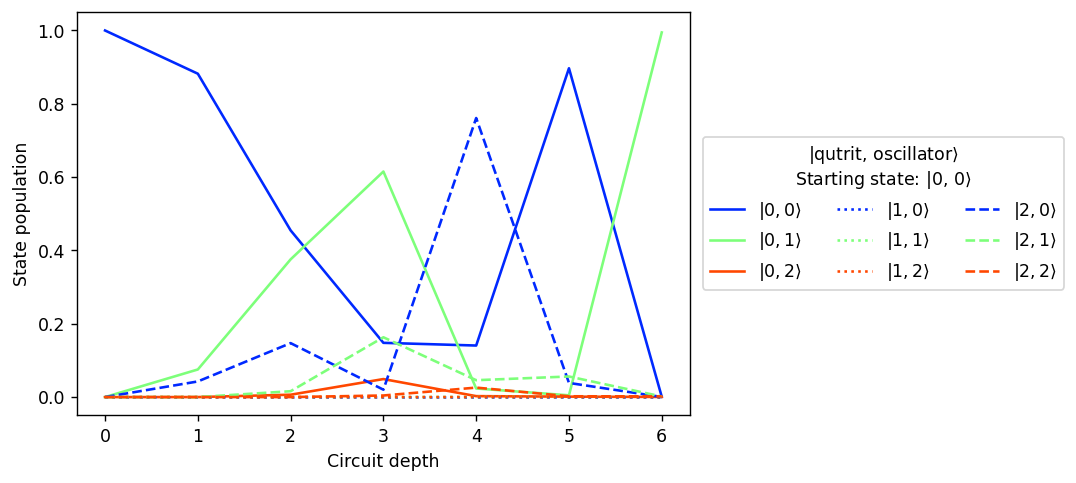

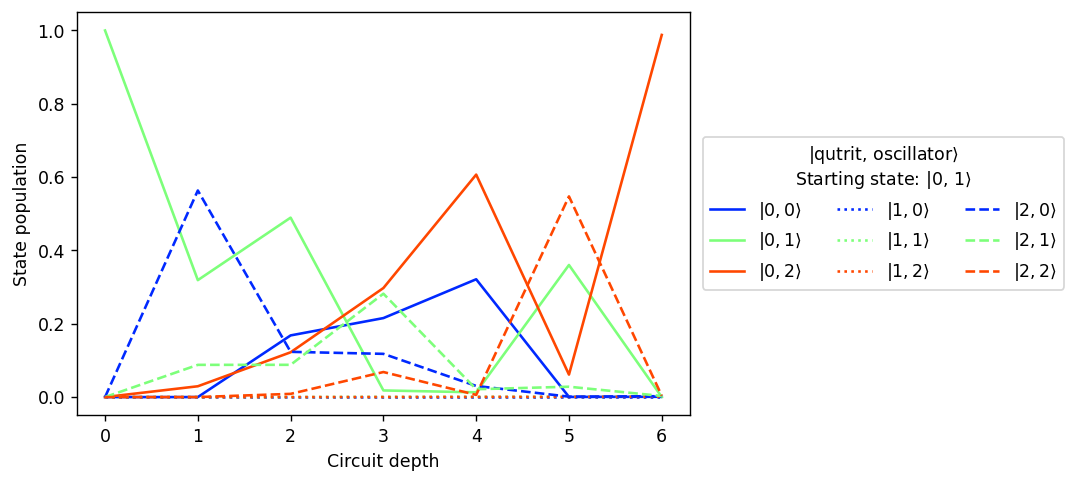

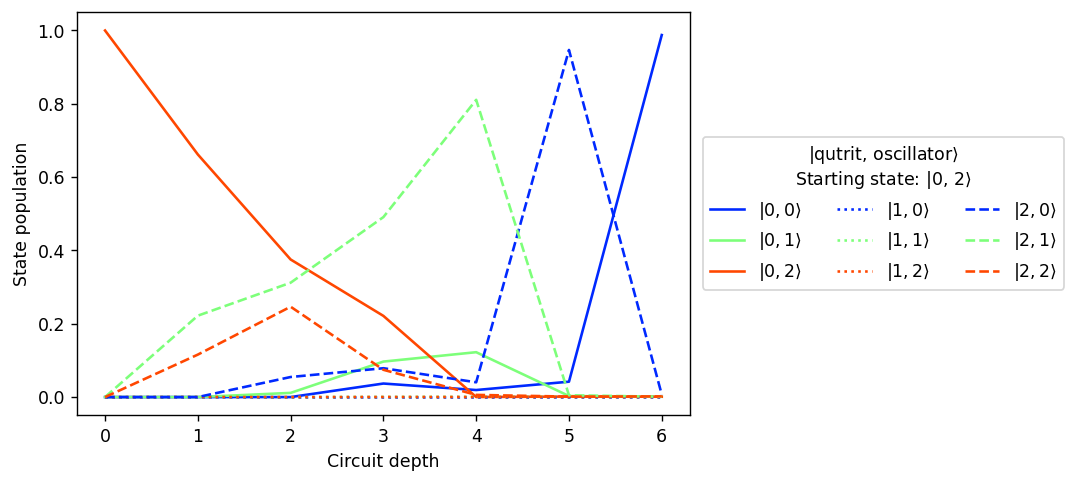

In [40]:
filepath = file_directory + '\\data\\' + '00000_shift_gate_n3_depth6.h5'
with h5py.File(filepath, 'r') as file:
    optimized_qubit_thetas = np.array(file['optimized_qubit_thetas'])
    optimized_qubit_phis = np.array(file['optimized_qubit_phis']) 
    optimized_sb_phis = np.array(file['optimized_sb_phis'])
    sb_thetas = np.array(file['optimized_sb_thetas'])
    sb_detunings = np.array(file['optimized_sb_detunings'])
    circuit_depth = file.attrs['circuit_depth']
    n_osc_max = file.attrs['n_osc_max']
    optimized_fidelity = file['optimized_fidelity'][()]
    epsilon = file.attrs['epsilon']
    epsilon_q = file.attrs['epsilon_q']
    chi_e = file.attrs['chi_e']
    chi_f = file.attrs['chi_f']
    tau_q = file.attrs['tau_q']
    stark_shift_e = file.attrs['stark_shift_e']
    sb_ramp_offset = file.attrs['sb_ramp_offset']
    unitary_target = np.array(file.attrs['unitary_target'])
    subspace_proj = np.array(file.attrs['subspace_proj'])
    stark_shift_osc = file.attrs['stark_shift_osc']
    stark_shift_f = file.attrs['stark_shift_f']

    utils = Utils(n_osc_max, stark_shift_f, stark_shift_e, stark_shift_osc, epsilon, epsilon_q, chi_e, chi_f, tau_q, sb_ramp_offset, qubit_pulse_theta='amp', verbose=True)
    unitary_target = utils.array_to_qobj(unitary_target)
    subspace_proj = utils.array_to_qobj(subspace_proj)
    
    float_formatter = lambda x: f"{x:.7f}"

    print('Best fidelity (PyTorch):', optimized_fidelity)
    print('Best fidelity (QuTiP):', np.abs((subspace_proj * unitary_target.dag() * utils.unitary_gate(optimized_qubit_thetas, optimized_qubit_phis, sb_thetas, optimized_sb_phis, sb_detunings)).tr() / subspace_proj.tr())**2 )
    print('Qubit theta (degree):', np.array2string(optimized_qubit_thetas * 180 / np.pi, separator=', ', formatter={'float_kind':float_formatter}))
    print('Qubit phi (degree):', np.array2string(optimized_qubit_phis * 180 / np.pi, separator=', ', formatter={'float_kind':float_formatter}))
    print('Sideband phi (degree):', np.array2string(optimized_sb_phis * 180 / np.pi, separator=', ', formatter={'float_kind':float_formatter}))
    print('Sideband detuning:', np.array2string(sb_detunings, separator=', ', formatter={'float_kind':float_formatter}))

    import matplotlib.colors as colors
    cmap = colormaps['jet']
    norm = colors.Normalize(vmin=-0.5, vmax=n_osc_max-0.5)

    starting_states_idx = [(0, ii) for ii in range(n_osc_max)]  # Starting states are (qubit state, oscillator Fock number)
    starting_states = [utils.get_state(ii[0], ii[1]) for ii in starting_states_idx]
    states = [utils.get_unitary_gate_state_evolution(ii, optimized_qubit_thetas, optimized_qubit_phis, sb_thetas, optimized_sb_phis, sb_detunings) for ii in starting_states]

    state_populations = np.array([[utils.get_state_populations(ii) for ii in jj] for jj in states])  # (starting_states, circuit_depth+1, qubit_hilb, oscillator_hilb)

    for ii in range(len(starting_states)):
        fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.75), layout='constrained', dpi=125)
        for kk in range(3):
            for jj in range(n_osc_max):
                if kk==0:
                    ax.plot(np.arange(circuit_depth+1), state_populations[ii, :, 0, jj], label=f'$|{0}, {jj}\\rangle$', linestyle='-', color=cmap(norm(jj)))
                elif kk==1:
                    ax.plot(np.arange(circuit_depth+1), state_populations[ii, :, 1, jj], label=f'$|{1}, {jj}\\rangle$', linestyle=':', color=cmap(norm(jj)))
                elif kk==2:
                    ax.plot(np.arange(circuit_depth+1), state_populations[ii, :, 2, jj], label=f'$|{2}, {jj}\\rangle$', linestyle='--', color=cmap(norm(jj)))
            
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel('State population')
        ax.set_xlabel('Circuit depth')

        leg = fig.legend(title=f'$|$qutrit, oscillator$\\rangle$\nStarting state: $|${starting_states_idx[ii][0]}, {starting_states_idx[ii][1]}$\\rangle$', ncol=3, loc='center right', bbox_to_anchor=(1.55, 0.56))
        leg.get_title().set_multialignment('center')

        

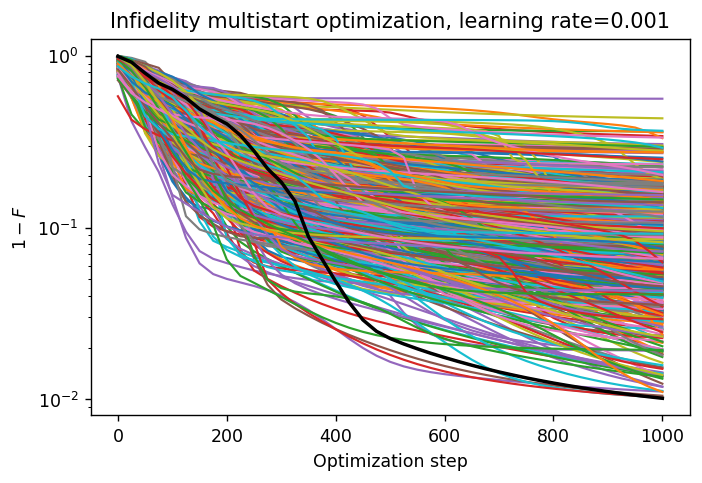

In [42]:
filepath = file_directory + "\\data\\" + '00000_shift_gate_n3_depth6.h5'
with h5py.File(filepath, 'r') as file:
    optimized_qubit_thetas = np.array(file['optimized_qubit_thetas'])
    optimized_qubit_phis = np.array(file['optimized_qubit_phis'])
    optimized_sb_phis = np.array(file['optimized_sb_phis'])
    sb_thetas = np.array(file['optimized_sb_thetas'])
    circuit_depth = file.attrs['circuit_depth']
    n_osc_max = file.attrs['n_osc_max']
    fidelities_path = np.array(file['fidelities_path'])
    learning_rate = file.attrs['learning_rate']

    skip_ind = 25
    fidelities_path = fidelities_path[::skip_ind]

    fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.75), layout='constrained', dpi=125)

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for ii in range(np.shape(fidelities_path)[1]): # Loop over initial guesses
        ax.plot(skip_ind * np.arange(np.shape(fidelities_path)[0]), 1 - np.array(fidelities_path)[:, ii], linestyle='-', color=colors[ii%len(colors)], linewidth=1.25)

    best_idx = np.argmax(fidelities_path[-1])
    ax.plot(skip_ind * np.arange(np.shape(fidelities_path)[0]), 1 - np.array(fidelities_path)[:, best_idx], linestyle='-', color='black', linewidth=2)

    ax.set_title('Infidelity multistart optimization, learning rate=' + str(learning_rate))
    ax.set_yscale('log')
    ax.set_xlabel('Optimization step')
    ax.set_ylabel('$1-F$')

# State transfer optimization

Here, we optimize a gate that takes $|0\rangle$ to $\frac{1}{\sqrt{2}}(|1\rangle + |2\rangle)$

In [ ]:
circuit_depth = 4
n_osc_max = 3

state_target_qutip =  (qt.tensor(qt.basis(n_osc_max, 1), qt.basis(3, 0)) + qt.tensor(qt.basis(n_osc_max, 2), qt.basis(3, 0))).unit()
state_initial_qutip = qt.tensor(qt.basis(n_osc_max, 0), qt.basis(3, 0))

state_target = state_target_qutip.full()
state_initial = state_initial_qutip.full()

config = {
    'epsilon':  0.7699611115611255,  
    'epsilon_q': 1 / 16 / 0.023251488095238096,
    'chi_e': -0.19878036671960797,
    'chi_f': -0.38271723554952297,
    'tau_q': 0.023251488095238096 * 4,
    'stark_shift_f': -13.715578950465964,
    'stark_shift_e': -13.715578950465964 / 2,
    'stark_shift_osc': 0.0,
    'sb_ramp_offset':0,
    'n_osc_max': n_osc_max,
    'target_fidelity': 1-1e-3,
    'num_starts': 1000,
    'steps': 1000,
    'learning_rate': .001,
    'delta_fid_stop': 1e-8,
    'circuit_depth': circuit_depth,
    'state_initial': state_initial,
    'state_target': state_target,
    # 'unitary_target': unitary_target,
    # 'subspace_proj': subspace_proj,
    'save_path': file_directory + '\\data',
    'filename': 'qudit' + str(n_osc_max) + '_depth' + str(circuit_depth) + '_state_prep_superposition',
    'save': True,
    'optimize_sb_detuning': False,
    'qubit_pulse_theta': 'amp'
}

optimizer = Batch_Optimizer(config)
results = optimizer.optimize()

Set up for state transfer optimization.
Step 1000/1000. Max fidelity: 0.99878, delta max fidelity: -0.00000, average fidelity: 0.96863
Data saved to: C:\Users\jah499\OneDrive - Rutgers University\Research\Sideband Optimal Control\optimizer_code\RELEASE_v1\data\00000_qudit3_depth4_state_prep_superposition.h5


Dynamical phase (QuTiP, degree) for 2pi sideband pulse resonant with |f, n_osc_max-1>-|g, n_osc_max> transition: 205.47134020446674
Best fidelity (PyTorch): 0.9987843036651611
Best fidelity (QuTiP): 0.9987834640898148
Qubit theta (degree): [231.8849945, 136.7238770, 102.9518661, 53.7842560]
Qubit phi (degree): [417.2263489, 145.5402069, -40.7444572, 78.8033447]
Sideband phi (degree): [319.5777283, 196.3289490, 164.8961945, 137.5363312]
Sideband detuning: [0.0000000, 0.0000000, 0.0000000, 0.0000000]


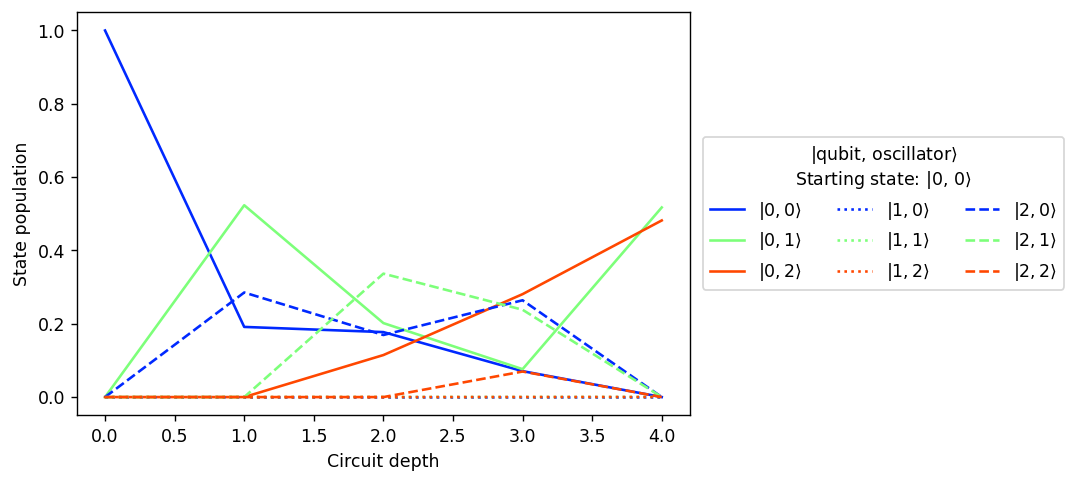

In [41]:
filepath = file_directory + '\\data\\' + "00000_qudit3_depth4_state_prep_superposition.h5"
with h5py.File(filepath, 'r') as file:
    optimized_qubit_thetas = np.array(file['optimized_qubit_thetas'])
    optimized_qubit_phis = np.array(file['optimized_qubit_phis']) 
    optimized_sb_phis = np.array(file['optimized_sb_phis'])
    sb_detunings = np.array(file['optimized_sb_detunings'])
    sb_thetas = np.array(file['optimized_sb_thetas'])
    circuit_depth = file.attrs['circuit_depth']
    n_osc_max = file.attrs['n_osc_max']
    optimized_fidelity = np.array(file['optimized_fidelity'])
    epsilon = file.attrs['epsilon']
    epsilon_q = file.attrs['epsilon_q']
    chi_e = file.attrs['chi_e']
    chi_f = file.attrs['chi_f']
    tau_q = file.attrs['tau_q']
    stark_shift_f = file.attrs['stark_shift_f']
    stark_shift_e = file.attrs['stark_shift_e']
    stark_shift_osc = file.attrs['stark_shift_osc']
    sb_ramp_offset = file.attrs['sb_ramp_offset']

    utils = Utils(n_osc_max, stark_shift_f, stark_shift_e, stark_shift_osc, epsilon, epsilon_q, chi_e, chi_f, tau_q, sb_ramp_offset, qubit_pulse_theta='amp', verbose=True)
    state_target = utils.array_to_qobj(np.array(file.attrs['state_target']))
    state_initial = utils.array_to_qobj(np.array(file.attrs['state_initial']))
    
    print('Best fidelity (PyTorch):', optimized_fidelity)
    print('Best fidelity (QuTiP):', np.abs((state_target.dag() * utils.unitary_gate(optimized_qubit_thetas, optimized_qubit_phis, sb_thetas, optimized_sb_phis, sb_detunings) * state_initial))**2)

    float_formatter = lambda x: f"{x:.7f}"

    print('Qubit theta (degree):', np.array2string(optimized_qubit_thetas * 180 / np.pi, separator=', ', formatter={'float_kind':float_formatter}))
    print('Qubit phi (degree):', np.array2string(optimized_qubit_phis * 180 / np.pi, separator=', ', formatter={'float_kind':float_formatter}))
    print('Sideband phi (degree):', np.array2string(optimized_sb_phis * 180 / np.pi, separator=', ', formatter={'float_kind':float_formatter}))
    print('Sideband detuning:', np.array2string(sb_detunings, separator=', ', formatter={'float_kind':float_formatter}))

    import matplotlib.colors as colors
    cmap = colormaps['jet']
    norm = colors.Normalize(vmin=-0.5, vmax=n_osc_max-0.5)

    starting_states_idx = [(0, ii) for ii in range(1)]  # Starting states are (qubit state, oscillator Fock number)
    starting_states = [utils.get_state(ii[0], ii[1]) for ii in starting_states_idx]
    states = [utils.get_unitary_gate_state_evolution(ii, optimized_qubit_thetas, optimized_qubit_phis, sb_thetas, optimized_sb_phis, sb_detunings) for ii in starting_states]
    state_populations = [[utils.get_state_populations(ii) for ii in jj] for jj in states]  # (starting_states, circuit_depth+1, qubit_hilb, oscillator_hilb)

    for ii in range(len(starting_states)):
        fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.75), layout='constrained', dpi=125)
        for kk in range(3):
            for jj in range(n_osc_max):
                if kk==0:
                    ax.plot(np.arange(circuit_depth+1), np.array(state_populations)[ii, :, 0, jj], label=f'$|{0}, {jj}\\rangle$', linestyle='-', color=cmap(norm(jj)))
                elif kk==1:
                    ax.plot(np.arange(circuit_depth+1), np.array(state_populations)[ii, :, 1, jj], label=f'$|{1}, {jj}\\rangle$', linestyle=':', color=cmap(norm(jj)))
                elif kk==2:
                    ax.plot(np.arange(circuit_depth+1), np.array(state_populations)[ii, :, 2, jj], label=f'$|{2}, {jj}\\rangle$', linestyle='--', color=cmap(norm(jj)))
            
        ax.set_ylabel('State population')
        ax.set_xlabel('Circuit depth')
        leg = fig.legend(title=f'$|$qubit, oscillator$\\rangle$\nStarting state: $|${starting_states_idx[ii][0]}, {starting_states_idx[ii][1]}$\\rangle$', ncol=3, loc='center right', bbox_to_anchor=(1.55, 0.56))
        leg.get_title().set_multialignment('center')


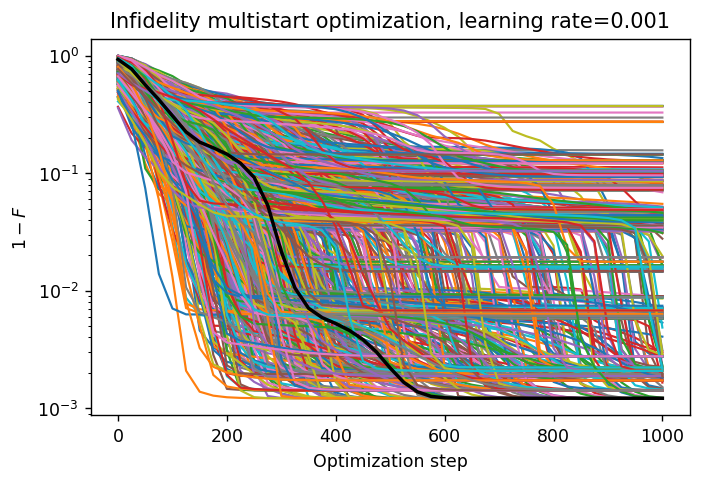

In [36]:
filepath = file_directory + "\\data\\" + "00000_qudit3_depth4_state_prep_superposition.h5"
with h5py.File(filepath, 'r') as file:
    optimized_qubit_thetas = np.array(file['optimized_qubit_thetas'])
    optimized_qubit_phis = np.array(file['optimized_qubit_phis'])
    optimized_sb_phis = np.array(file['optimized_sb_phis'])
    sb_thetas = np.array(file['optimized_sb_thetas'])
    circuit_depth = file.attrs['circuit_depth']
    n_osc_max = file.attrs['n_osc_max']
    fidelities_path = np.array(file['fidelities_path'])
    learning_rate = file.attrs['learning_rate']

    skip_ind = 25
    fidelities_path = fidelities_path[::skip_ind]

    fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.75), layout='constrained', dpi=125)

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for ii in range(np.shape(fidelities_path)[1]): # Loop over initial guesses
        ax.plot(skip_ind * np.arange(np.shape(fidelities_path)[0]), 1 - np.array(fidelities_path)[:, ii], linestyle='-', color=colors[ii%len(colors)], linewidth=1.25)

    best_idx = np.argmax(fidelities_path[-1])
    ax.plot(skip_ind * np.arange(np.shape(fidelities_path)[0]), 1 - np.array(fidelities_path)[:, best_idx], linestyle='-', color='black', linewidth=2)

    ax.set_title('Infidelity multistart optimization, learning rate=' + str(learning_rate))
    ax.set_yscale('log')
    ax.set_xlabel('Optimization step')
    ax.set_ylabel('$1-F$')